# Automated Pipeline Overview

## Overview

VAFT's production processing runs as Snakemake workflows under `workflow/`.
This page reports what is actually there — the pipelines, their rules, and what
each one produces — by reading the directory rather than describing it from
memory, so the picture cannot drift from the pipeline it documents.

## Pipeline context

The entry point for the rest of the collection: every notebook that starts from
a processed ODS is reading something one of these rules wrote.

In [ ]:
import json
import os
import re
from pathlib import Path

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

WORKFLOW = _repo_root / "workflow"
RULE = re.compile(r"^rule\s+(\w+)\s*:", re.M)


def describe(directory):
    """What one workflow directory holds: its rules, scripts, and stated purpose."""
    snakefile = directory / "Snakefile"
    rules = [name for name in RULE.findall(snakefile.read_text()) if name != "all"] if snakefile.exists() else []
    readme = directory / "README.md"
    purpose = ""
    if readme.exists():
        for line in readme.read_text().splitlines():
            stripped = line.strip()
            if stripped and not stripped.startswith("#"):
                purpose = stripped
                break
    return {
        "name": directory.name,
        "driver": "Snakemake" if snakefile.exists() else "scripts",
        "rules": rules,
        "scripts": sorted(path.name for path in directory.glob("*.py")),
        "purpose": purpose,
    }


workflows = [describe(path) for path in sorted(WORKFLOW.iterdir()) if path.is_dir()]

print(f"{'directory':46s} {'driver':10s} {'rules':>6s} {'scripts':>8s}")
for item in workflows:
    print(f"{item['name']:46s} {item['driver']:10s} {len(item['rules']):6d} {len(item['scripts']):8d}")

directory                                      driver      rules  scripts
automatic_pipeline_1_routine_data_processing   Snakemake      14       20
automatic_pipeline_2_corrective_data_update    scripts         0        6
automatic_pipeline_3_data_summary              Snakemake       7       16
efit_channel_selection                         scripts         0        1
em_coupling                                    scripts         0        1
plasma_onset                                   scripts         0        2
reference_validation                           scripts         0        5
vacuum_benchmark                               scripts         0        1


## The routine pipeline, rule by rule

Pipeline 1 is the one that turns a shot into processed data. Its rules are the
stages, in the order the Snakefile declares them, and each name says what it
writes.

In [ ]:
routine = next(item for item in workflows if item["name"].startswith("automatic_pipeline_1"))
print(routine["purpose"])
print()
for index, rule in enumerate(routine["rules"], start=1):
    print(f"  {index:2d}. {rule}")

The maintained VEST production pipeline. `workflow/main` was folded into this

   1. generate_raw_db_dump
   2. generate_static_ods
   3. generate_impa_ods
   4. generate_diagnostics_ods
   5. generate_eddy_ods
   6. generate_constraints_ods
   7. generate_kfile
   8. run_efit_reconstruction
   9. generate_efit_ods
  10. run_chease
  11. generate_chease_ods
  12. run_gpec_module
  13. build_mhd_linear
  14. build_gpec_ideal


## What the whole set produces

Three numbered pipelines and five supporting directories. The numbered ones are
the production path; the rest are procedures kept beside it — a channel-selection
backtest, a coupling regeneration, an onset review, a reference capture and a
vacuum benchmark. Only the first and third are Snakemake-driven; the second is a
set of scripts run by hand against the corrective source.

In [ ]:
for item in workflows:
    stages = ", ".join(item["rules"][:4]) + (" ..." if len(item["rules"]) > 4 else "")
    print(f"- {item['name']}")
    count = len(item["rules"]) if item["rules"] else len(item["scripts"])
    unit = "rule" if item["rules"] else "script"
    print(f"    driver: {item['driver']}, {count} {unit}{'s' if count != 1 else ''}")
    if stages.strip(" ."):
        print(f"    rules: {stages}")
    if item["purpose"]:
        print(f"    purpose: {item['purpose'][:110]}")

- automatic_pipeline_1_routine_data_processing
    driver: Snakemake, 14 rules
    rules: generate_raw_db_dump, generate_static_ods, generate_impa_ods, generate_diagnostics_ods ...
    purpose: The maintained VEST production pipeline. `workflow/main` was folded into this
- automatic_pipeline_2_corrective_data_update
    driver: scripts, 6 scripts
- automatic_pipeline_3_data_summary
    driver: Snakemake, 7 rules
    rules: generate_chease_history, generate_efit_history, generate_equilibrium_global_history, generate_core_profiles_history ...
    purpose: Database-backed history scripts are thin wrappers around
- efit_channel_selection
    driver: scripts, 1 script
    purpose: The routine EFIT configuration
- em_coupling
    driver: scripts, 1 script
    purpose: `vaft/data/geometry/VEST_em_coupling_pf_versions.npz` holds the five mutual
- plasma_onset
    driver: scripts, 2 scripts
- reference_validation
    driver: scripts, 5 scripts
    purpose: This directory contains the reproducib

## The stages, drawn

The same rule names as boxes, so the figure and the table cannot disagree.

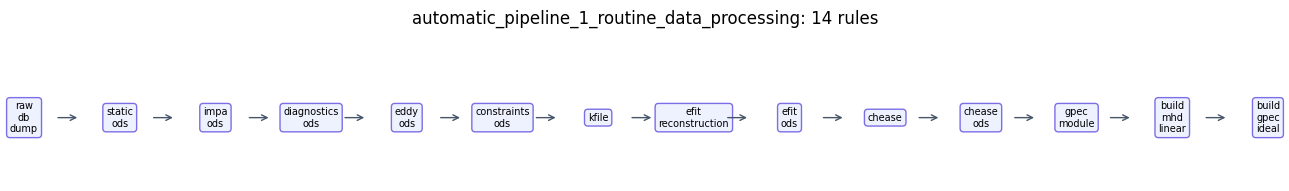

{
  "directory": "automatic_pipeline_1_routine_data_processing",
  "driver": "Snakemake",
  "rules": [
    "generate_raw_db_dump",
    "generate_static_ods",
    "generate_impa_ods",
    "generate_diagnostics_ods",
    "generate_eddy_ods",
    "generate_constraints_ods",
    "generate_kfile",
    "run_efit_reconstruction",
    "generate_efit_ods",
    "run_chease",
    "generate_chease_ods",
    "run_gpec_module",
    "build_mhd_linear",
    "build_gpec_ideal"
  ],
  "script_count": 20
}


In [ ]:
stages = routine["rules"]
fig, ax = plt.subplots(figsize=(13, 1.9))
ax.axis("off")
ax.set_ylim(0.35, 0.75)
for index, rule in enumerate(stages):
    x = index / max(len(stages) - 1, 1)
    ax.text(x, 0.55, rule.replace("generate_", "").replace("run_", "").replace("_", "\n"),
            ha="center", va="center", fontsize=7,
            bbox={"boxstyle": "round,pad=0.35", "fc": "#eef2ff", "ec": "#7c6ee6"})
    if index < len(stages) - 1:
        ax.annotate("", xy=(x + 0.045, 0.55), xytext=(x + 0.025, 0.55),
                    arrowprops={"arrowstyle": "->", "color": "#475569"})
fig.suptitle(f"{routine['name']}: {len(stages)} rules")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pipeline-overview.png", dpi=180, bbox_inches="tight")
plt.show()

summary = [
    {
        "directory": item["name"],
        "driver": item["driver"],
        "rules": item["rules"],
        "script_count": len(item["scripts"]),
    }
    for item in workflows
]
(OUTPUT_DIR / "pipeline-overview.txt").write_text(json.dumps(summary, indent=2) + "\n")
print(json.dumps(summary[0], indent=2))

## Reading this against the notebooks

`notebooks/README.md` groups the collection by pipeline stage. A rule name above
is the thing a notebook's inputs came from: `generate_diagnostics_ods` for the
magnetics pages, `run_efit_reconstruction` for the equilibrium ones, the
pipeline-3 history rules for the campaign-scale analyses.